In [1]:
%cd /home/aistudio
import os
import cv2
import tqdm

def make_new_dir(root_dir, tag, save_dir):
    img_root = os.path.join(root_dir, tag)
    img_dir_list = os.listdir(img_root)
    if not os.path.isdir(save_dir):
        os.mkdir(save_dir)
    print(img_dir_list)
    for img_dir in tqdm.tqdm(img_dir_list):
        img_folder = os.path.join(img_root, img_dir)
        img_list = [f for f in os.listdir(img_folder) if f.endswith('.jpg')]
        name_first = img_dir[:2].upper()
        for index, filename in enumerate(img_list):
            img = cv2.imread(os.path.join(img_folder, filename), -1)
            save_name = name_first+"{0:0>5}.jpg".format(index)
            cv2.imwrite(os.path.join(save_dir, save_name), img)


# 随机移动10%数量的图像到val文件夹中
import shutil
import os
import random

def move2newDir(inputFolder, saveFolder):
    filenames = [f for f in os.listdir(inputFolder) if f.endswith('.jpg')]
    random.shuffle(filenames)
    num_val = int(0.1*len(filenames))
    if not os.path.isdir(saveFolder):
        os.mkdir(saveFolder)
        
    for index, filename in enumerate(filenames):  
        src = os.path.join(inputFolder,filename)
        dst = os.path.join(saveFolder,filename)       
        shutil.move(src, dst)
        if index == num_val:
            break
# !rm -rf ./images

# !unzip images.zip
!rm -rf  test/

# root_dir = r"emotic"
# save_dir = r"train"
# make_new_dir(root_dir, "train", save_dir) # 制作训练集

root_dir = r"emotic"
save_dir = r"test"
make_new_dir(root_dir, "test", save_dir) # 制作测试集

# inputFolder = r"train"
# saveFolder = r"val"
# move2newDir(inputFolder, saveFolder)

/home/aistudio
['sad', 'happy', 'angry', 'fear', 'neutral', 'disgust', 'surprise']


100%|██████████| 7/7 [00:02<00:00,  2.79it/s]


In [2]:
# 生成数据集
import os
import cv2
import numpy as np
from paddle.io import Dataset
from matplotlib import pyplot as plt

# 生成label

class MyDataset(Dataset):
    """
    步骤一：继承 paddle.io.Dataset 类
    """
    def __init__(self, data_dir, transform=None):
        """
        步骤二：实现 __init__ 函数，初始化数据集，将样本和标签映射到列表中
        """
        super(MyDataset, self).__init__()
        self.data_list = []
        filenames = os.listdir(data_dir)
        for name in filenames:
            if name[:2] == 'SA':
                label = 0 
            elif name[:2] == 'DI':
                label = 1
            elif name[:2] == 'HA':
                label = 2
            elif name[:2] == 'FE':
                label = 3 
            elif name[:2] == 'SU':
                label = 4
            elif name[:2] == 'NE':
                label = 5
            elif name[:2] == 'AN':
                label = 6
            else:
                print(name)
                continue
            image_path = os.path.join(data_dir, name)
            self.data_list.append([image_path, label])
        print(len(self.data_list))
        print(self.data_list[-10:])
        # 传入定义好的数据处理方法，作为自定义数据集类的一个属性
        self.transform = transform

    def __getitem__(self, index):
        """
        步骤三：实现 __getitem__ 函数，定义指定 index 时如何获取数据，并返回单条数据（样本数据、对应的标签）
        """
        # 根据索引，从列表中取出一个图像
        image_path, label = self.data_list[index]
        # 读取灰度图
        image = cv2.imread(image_path)
        # 将图片尺寸缩放道 224x224
        image = cv2.resize(image, (224, 224))
        # 读入的图像数据格式是[H, W, C]
        # 使用转置操作将其变成[C, H, W]
        image = np.transpose(image, (2,0,1))
        image = image.astype('float32')
        # 将数据范围调整到[-1.0, 1.0]之间
        image = image / 255.
        image = image * 2.0 - 1.0
    
        # if self.transform is not None:
        #     image = self.transform(image)
        # # 飞桨训练时内部数据格式默认为float32，将图像数据格式转换为 float32
        # image = image.astype('float32')
        # image = image.transpose(2, 0, 1)
        # print(image.shape)
        # 应用数据处理方法到图像上

        # CrossEntropyLoss要求label格式为int，将Label格式转换为 int
        label = int(label)
        # 返回图像和对应标签
        return image, label
    def show_image(self,id):
        for i in range(20):
            plt.subplot(4,5,i+1)
            image = cv2.imread(self.data_list[id+i][0])
            plt.imshow(image)
    def set_len(self,lenth):
        self.data_list = self.data_list[:lenth]
    def __len__(self):
        """
        步骤四：实现 __len__ 函数，返回数据集的样本总数
        """
        return len(self.data_list)
print("prepare date")
from paddle.vision.transforms import Compose, RandomRotation,Resize,Normalize,RandomHorizontalFlip
# transform = Normalize(mean=[127.5], std=[127.5], data_format='CHW')
transform = Compose([RandomRotation(20),RandomHorizontalFlip(0.5),Resize(size = 48)])
# 打印数据集样本数        
train_dataset = MyDataset('train',transform)
val_dataset = MyDataset('test',transform)

print('train_custom_dataset images: ',len(train_dataset), 'test_custom_dataset images: ',len(val_dataset))


/opt/conda/envs/python35-paddle120-env/lib/python3.7/site-packages/matplotlib/__init__.py:107: DeprecationWarning: Using or importing the ABCs from 'collections' instead of from 'collections.abc' is deprecated, and in 3.8 it will stop working
  from collections import MutableMapping
/opt/conda/envs/python35-paddle120-env/lib/python3.7/site-packages/matplotlib/rcsetup.py:20: DeprecationWarning: Using or importing the ABCs from 'collections' instead of from 'collections.abc' is deprecated, and in 3.8 it will stop working
  from collections import Iterable, Mapping
/opt/conda/envs/python35-paddle120-env/lib/python3.7/site-packages/matplotlib/colors.py:53: DeprecationWarning: Using or importing the ABCs from 'collections' instead of from 'collections.abc' is deprecated, and in 3.8 it will stop working
  from collections import Sized


prepare date
38794
[['train/SU17262.jpg', 4], ['train/AN17180.jpg', 6], ['train/HA14617.jpg', 2], ['train/FE17386.jpg', 3], ['train/SA14658.jpg', 0], ['train/HA19579.jpg', 2], ['train/NE00825.jpg', 5], ['train/NE00053.jpg', 5], ['train/AN17082.jpg', 6], ['train/HA14495.jpg', 2]]
7178
[['test/SU00200.jpg', 4], ['test/HA00956.jpg', 2], ['test/FE00666.jpg', 3], ['test/HA01695.jpg', 2], ['test/HA00149.jpg', 2], ['test/FE01010.jpg', 3], ['test/SA01231.jpg', 0], ['test/SA01083.jpg', 0], ['test/FE00487.jpg', 3], ['test/SU00330.jpg', 4]]
train_custom_dataset images:  38794 test_custom_dataset images:  7178


In [3]:
import paddle
from paddle.vision.models import MobileNetV2,mobilenet_v2

print('飞桨框架内置模型：', paddle.vision.models.__all__)
network =paddle.vision.models.mobilenet_v2(pretrained=True,num_classes=7)
model = paddle.Model(network)
#训练
# 指定在 CPU 上训练
paddle.device.set_device('cpu')

# 指定在 GPU 第 0 号卡上训练
# paddle.device.set_device('gpu:0')
# 重新加载模型
params_file_path = '/home/aistudio/checkpoint/mobilenet_v2'
model.load(params_file_path)
model.prepare(paddle.optimizer.Adam(learning_rate=0.001,parameters=model.parameters()),
              paddle.nn.CrossEntropyLoss(),
              paddle.metric.Accuracy())


飞桨框架内置模型： ['ResNet', 'resnet18', 'resnet34', 'resnet50', 'resnet101', 'resnet152', 'VGG', 'vgg11', 'vgg13', 'vgg16', 'vgg19', 'MobileNetV1', 'mobilenet_v1', 'MobileNetV2', 'mobilenet_v2', 'LeNet']


W1203 09:26:28.010524   354 device_context.cc:447] Please NOTE: device: 0, GPU Compute Capability: 7.0, Driver API Version: 11.2, Runtime API Version: 10.1
W1203 09:26:28.016391   354 device_context.cc:465] device: 0, cuDNN Version: 7.6.
100%|██████████| 20795/20795 [00:00<00:00, 30178.77it/s]
/opt/conda/envs/python35-paddle120-env/lib/python3.7/site-packages/paddle/fluid/dygraph/layers.py:1441: UserWarning: Skip loading for classifier.1.weight. classifier.1.weight receives a shape [1280, 1000], but the expected shape is [1280, 7].
  warnings.warn(("Skip loading for {}. ".format(key) + str(err)))
/opt/conda/envs/python35-paddle120-env/lib/python3.7/site-packages/paddle/fluid/dygraph/layers.py:1441: UserWarning: Skip loading for classifier.1.bias. classifier.1.bias receives a shape [1000], but the expected shape is [7].
  warnings.warn(("Skip loading for {}. ".format(key) + str(err)))


## 预测与导出


/opt/conda/envs/python35-paddle120-env/lib/python3.7/site-packages/paddle/fluid/layers/utils.py:77: DeprecationWarning: Using or importing the ABCs from 'collections' instead of from 'collections.abc' is deprecated, and in 3.8 it will stop working
  return (isinstance(seq, collections.Sequence) and


Predict begin...
step 30/30 [==============================] - 57ms/step          
Predict samples: 30
0.6
[['SA|HA' 'FE|FE' 'SU|SU' 'SA|NE' 'SA|SA']
 ['SA|SA' 'AN|AN' 'HA|NE' 'SA|NE' 'SU|SU']
 ['FE|NE' 'SA|SA' 'AN|AN' 'FE|SU' 'SA|NE']
 ['AN|NE' 'HA|HA' 'SU|SA' 'HA|HA' 'SU|SU']]


/opt/conda/envs/python35-paddle120-env/lib/python3.7/site-packages/matplotlib/cbook/__init__.py:2349: DeprecationWarning: Using or importing the ABCs from 'collections' instead of from 'collections.abc' is deprecated, and in 3.8 it will stop working
  if isinstance(obj, collections.Iterator):
/opt/conda/envs/python35-paddle120-env/lib/python3.7/site-packages/matplotlib/cbook/__init__.py:2366: DeprecationWarning: Using or importing the ABCs from 'collections' instead of from 'collections.abc' is deprecated, and in 3.8 it will stop working
  return list(data) if isinstance(data, collections.MappingView) else data


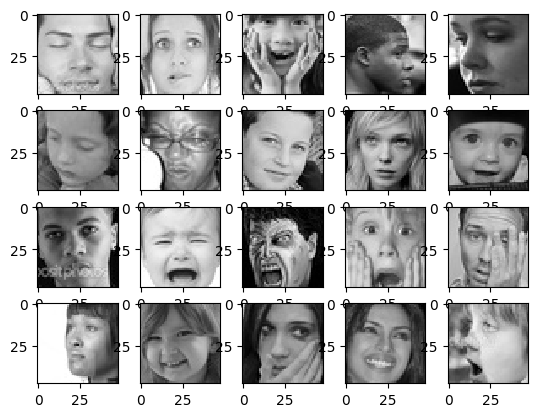

In [4]:
# 加载测试数据集
test_loader = paddle.io.DataLoader(val_dataset, batch_size=1, drop_last=True)
# 将该模型及其所有子层设置为预测模式
result_dict = {0:"SA",1:"DI",2:"HA",3:"FE",4:"SU",5:"NE",6:"AN"}
val_dataset.set_len(30)
test_result = model.predict(test_loader,verbose=1)
pred_labels = []
true_num=0
for i,data in enumerate(val_dataset):
    img, label = data
    # 打印推理结果，这里的argmax函数用于取出预测值中概率最高的一个的下标，作为预测标签
    pred_label = test_result[0][i].argmax()
    pred_labels.append(result_dict[pred_label]+"|"+result_dict[label])
    # print('{} true label: {}, pred label: {} {}'.format(val_dataset.data_list[i],result_dict[label], result_dict[pred_label],label==pred_label))
    if label == pred_label:
        true_num+=1
print(true_num/len(val_dataset))
val_dataset.show_image(0)
import numpy as np
print(np.array(pred_labels[:20]).reshape(4,5))



In [5]:
!pip install paddle2onnx
!pip install onnx==1.8.0

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 2.9 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip available: 22.1.2 -> 22.3.1
[notice] To update, run: pip install --upgrade pip
Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 4.2 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip available: 22.1.2 -> 22.3.1
[notice] To update, run: pip install --upgrade pip


In [6]:
import os
import time
import paddle


# 将模型设置为评估状态
# result = model.evaluate(val_dataset, verbose=1,batch_size=10)
# print(result)
# 定义输入数据
input_spec = paddle.static.InputSpec(shape=[1,3, 224, 224], dtype='float32', name='image')

# ONNX模型导出
paddle.onnx.export(network,"output/mobilenet_v2", input_spec=[input_spec], opset_version=10)


/opt/conda/envs/python35-paddle120-env/lib/python3.7/site-packages/paddle/fluid/dygraph/dygraph_to_static/convert_call_func.py:93: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  func_in_dict = func == v


2022-12-03 09:26:49 [INFO]	Static PaddlePaddle model saved in output/paddle_model_static_onnx_temp_dir.
[Paddle2ONNX] Start to parse PaddlePaddle model...
[Paddle2ONNX] Model file path: output/paddle_model_static_onnx_temp_dir/model.pdmodel
[Paddle2ONNX] Paramters file path: output/paddle_model_static_onnx_temp_dir/model.pdiparams
[Paddle2ONNX] Start to parsing Paddle model...
[Paddle2ONNX] Use opset_version = 10 for ONNX export.
[Paddle2ONNX] PaddlePaddle model is exported as ONNX format now.
2022-12-03 09:26:50 [INFO]	ONNX model saved in output/mobilenet_v2.onnx.


In [7]:
# 更改 ONNX 库版本,让低版本也可以用
import onnx
# 载入 ONNX 模型
onnx_model = onnx.load("output/mobilenet_v2.onnx")
# 使用 ONNX 库检查 ONNX 模型是否合理
# check = onnx.checker.check_model(onnx_model)
# # 打印检查结果
# print('check: ', check)
# onnx_model.graph.input[0].type.tensor_type.shape.dim[0].dim_param = '?'
onnx_model.ir_version = 6
onnx.save_model(onnx_model, "output/mobilenet_v2_onnx6.onnx")
# onnx.save(onnx_model, 'output/testModelOutput.onnx')

/opt/conda/envs/python35-paddle120-env/lib/python3.7/site-packages/onnx/mapping.py:25: DeprecationWarning: `np.object` is a deprecated alias for the builtin `object`. To silence this warning, use `object` by itself. Doing this will not modify any behavior and is safe. 
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  int(TensorProto.STRING): np.dtype(np.object)


In [8]:
# import os
# import time
# import paddle

# from paddle.vision.models import MobileNetV2,mobilenet_v2
# model = mobilenet_v2(pretrained=False,num_classes=7)
# # 加载预训练模型参数
# model.set_dict(paddle.load('checkpoint/mobilenet_v2.pdparams'))

# # 将模型设置为评估状态
# model.eval()

# # 定义输入数据
# input_spec = paddle.static.InputSpec(shape=[None, 3, 48, 48], dtype='float32', name='image')

# # ONNX模型导出
# paddle.onnx.export(model, 'output/test', input_spec=[input_spec], opset_version=10)


In [9]:
!pip install onnx

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple

[notice] A new release of pip available: 22.1.2 -> 22.3.1
[notice] To update, run: pip install --upgrade pip


In [10]:
# 使用onnxruntime
!pip install onnxruntime


Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 5.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.7/15.7 MB 5.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.4/6.4 MB 2.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 300.5 kB/s eta 0:00:00 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.6/532.6 kB 2.3 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 1.20.3
    Uninstalling numpy-1.20.3:
      Successfully uninstalled numpy-1.20.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
parl 1.4.1 requires pyzmq==18.1.1, but you have pyzmq 23.2.1 which is incompatible.

[no

In [11]:
# 动态图导出的ONNX模型测试
import time
import numpy as np
import cv2
from onnxruntime import InferenceSession

# result_dict = {0:"SA",1:"DI",2:"HA",3:"FE",4:"SU",5:"NE",6:"AN"}
# name =[result_dict[i] for i in range(7)]
# #直接加载图片
# data_dir="upload_image"
# filenames = os.listdir(data_dir)
# for name in filenames:
#     image_path = os.path.join(data_dir, name)
#     image = cv2.imread(image_path)
#     face_locations = face_recognition.face_locations(image)
#     image= cv2.resize(image,(48,48))
#     image = image.astype('float32')
#     image = image.transpose(2, 0, 1)
#     print(image.shape)
#     start = time.time()
#     d0 = model.run(output_names=None, input_feed={'image': x})
#     pred_label = np.array(d0[0][0]).argmax()
#     print(pred_label,label,pred_label==label)
#     if pred_label==label:
#         true_num+=1
#     end = time.time()
#     print('predict time: %.04f s' % (end - start))
# 用测试集使用ONNX模型
model_InferenceSession = InferenceSession('output/mobilenet_v2.onnx')
true_num = 0
for image,label in val_dataset:
    x = np.array([image])
    # 准备输入
    # x = np.random.random((1, 3, 48, 48)).astype('float32')
    # 速度测试
    start = time.time()
    d0 = model_InferenceSession.run(output_names=None, input_feed={'image': x})
    pred_label = np.array(d0[0][0]).argmax()
    print(pred_label,label,pred_label==label)
    if pred_label==label:
        true_num+=1
    end = time.time()
    print('predict time: %.04f s' % (end - start))
print(true_num/len(val_dataset))

0 2 False
predict time: 0.0042 s
3 3 True
predict time: 0.0482 s
4 4 True
predict time: 0.0028 s
0 5 False
predict time: 0.0028 s
0 0 True
predict time: 0.0879 s
0 0 True
predict time: 0.0031 s
6 6 True
predict time: 0.0028 s
2 5 False
predict time: 0.0880 s
0 5 False
predict time: 0.0030 s
4 4 True
predict time: 0.0026 s
3 5 False
predict time: 0.0909 s
0 0 True
predict time: 0.0033 s
6 6 True
predict time: 0.0025 s
3 4 False
predict time: 0.0917 s
0 5 False
predict time: 0.0029 s
6 5 False
predict time: 0.0027 s
2 2 True
predict time: 0.0877 s
4 0 False
predict time: 0.0030 s
2 2 True
predict time: 0.0028 s
4 4 True
predict time: 0.0913 s
2 2 True
predict time: 0.0028 s
3 3 True
predict time: 0.0028 s
4 4 True
predict time: 0.0879 s
4 2 False
predict time: 0.0030 s
5 5 True
predict time: 0.0027 s
3 6 False
predict time: 0.0911 s
4 4 True
predict time: 0.0028 s
3 5 False
predict time: 0.0026 s
2 2 True
predict time: 0.0032 s
2 2 True
predict time: 0.0030 s
0.6


In [12]:
# opencv 推理
# import cv2
# net = cv2.dnn.readNetFromONNX("output/dynamic_model.onnx")  # 加载训练好的识别模型
# image = cv2.imread("test/SU00227.jpg")  # 读取图片
# blob = cv2.dnn.blobFromImage(image,size=(48,48))  # 由图片加载数据 这里还可以进行缩放、归一化等预处理
# print(blob)
# net.setInput(blob)  # 设置模型输入
# out = net.forward()  # 推理出结果


error: OpenCV(4.6.0) /io/opencv/modules/dnn/src/onnx/onnx_importer.cpp:255: error: (-5:Bad argument) Can't read ONNX file: output/dynamic_model.onnx in function 'ONNXImporter'
